<a href="https://colab.research.google.com/github/sdtasneem/AIDS-Projects/blob/main/Brain_Tumor_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import TensorFlow and Keras for building and training the CNN model
# Import layers and models for creating the neural network
# ImageDataGenerator is used for loading and preprocessing image data
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Check the files available in the brain tumor project directory
import os
os.listdir("/content/drive/MyDrive/Colab Notebooks/brain tumor")


['archive (3).zip']

In [ ]:
# Import zipfile to extract the compressed dataset
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/brain tumor/archive (3).zip"
extract_path = "/content/drive/MyDrive/Colab Notebooks/brain tumor/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully")


Extraction completed successfully


In [ ]:
# Verify that the dataset files were extracted successfully
import os
os.listdir("/content/drive/MyDrive/Colab Notebooks/brain tumor")



['archive (3).zip', 'Testing', 'Training']

In [ ]:
# Create image generators for training and testing data
# Rescale pixel values from 0-255 to 0-1 for normalization
train_gen=ImageDataGenerator(rescale=1./255)
test_gen=ImageDataGenerator(rescale=1./255)

In [ ]:
# Define the paths to the training and testing datasets
train_path="/content/drive/MyDrive/Colab Notebooks/brain tumor/Training"
test_path="/content/drive/MyDrive/Colab Notebooks/brain tumor/Testing"

In [ ]:
# Load training images from their respective class folders
# Resize images to 224x224 pixels
# Convert images to grayscale
# Use categorical labels for multi-class classification
train_data=train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical"
)

Found 5712 images belonging to 4 classes.


In [ ]:
# Load testing images using the same preprocessing as the training data
# Images are resized to 224x224 and converted to grayscale
test_data=test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical"
)

Found 1311 images belonging to 4 classes.


In [ ]:
# Get the mapping between tumor class names and their numerical labels
classes=train_data.class_indices

In [ ]:
# Display the class-to-index mapping
classes

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

In [ ]:
# Extract the tumor class names from the class mapping
names=list(classes.keys())

In [ ]:
# Display the list of tumor classes
names

['glioma', 'meningioma', 'notumor', 'pituitary']

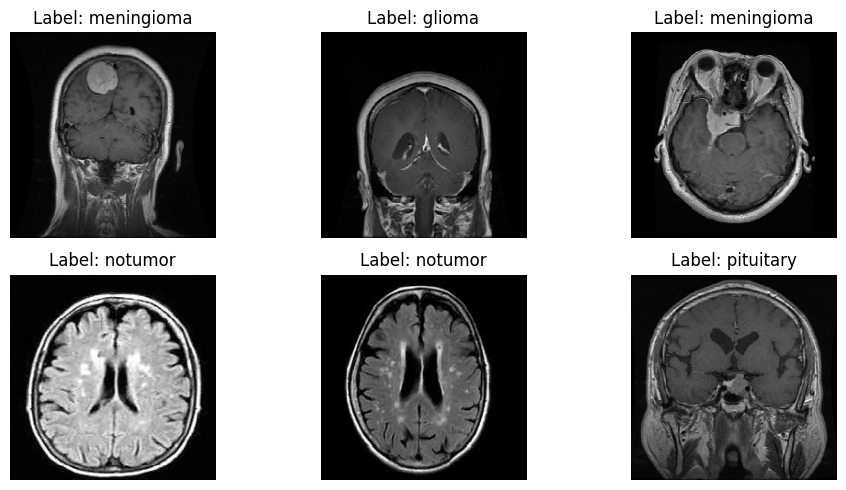

In [ ]:
# Import libraries for image visualization and numerical operations
import matplotlib.pyplot as plt
import numpy as np
# Get a batch of images and their corresponding labels
images, labels = next(train_data)
# Display six sample images from the training dataset
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    # Display the grayscale image
    plt.imshow(images[i].reshape(224,224), cmap='gray')
    # Find the numerical class index
    label_index=np.argmax(labels[i])
    # Convert the numerical index to the class name
    label_name=names[label_index]
    # Display the class name above the image
    plt.title(f"Label: {label_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Define the Convolutional Neural Network architecture
def cnn_model():
    model = models.Sequential([
        layers.Input(shape=(224,224,1)),

        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),
        layers.BatchNormalization(),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),
        layers.BatchNormalization(),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(4, activation="softmax")
    ])
    return model


In [ ]:
# Create an instance of the CNN model
initial_model=cnn_model()

In [ ]:
# Compile the CNN model
initial_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

In [ ]:
# Import Keras callbacks
from tensorflow.keras import callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [ ]:
# Train the CNN model using the training dataset
history = initial_model.fit(
    train_data,
    epochs=50,
    validation_data=test_data,
    callbacks=[early_stopping]
)


Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.4685 - loss: 4.4262

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 52s 238ms/step - accuracy: 0.4684 - loss: 4.4142 - val_accuracy: 0.2288 - val_loss: 6.3241
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 36s 200ms/step - accuracy: 0.5053 - loss: 1.1754 - val_accuracy: 0.2792 - val_loss: 4.5900
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 195ms/step - accuracy: 0.5267 - loss: 1.0324 - val_accuracy: 0.4470 - val_loss: 1.3173
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 195ms/step - accuracy: 0.5750 - loss: 0.9294 - val_accuracy: 0.5256 - val_loss: 1.1181
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.5943 - loss: 0.8548 - val_accuracy: 0.6217 - val_loss: 0.8633
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 221ms/step - accuracy: 0.6455 - loss: 0.7778 - val_accuracy: 0.7407 - val_loss: 0.7437
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.7396 - loss: 0.6291 - val_accuracy: 0.7483 - val_loss: 0.6990
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 36s 201ms/step - accuracy: 0.7527 - loss: 0.6503 - val

In [ ]:
# Save the trained CNN model
initial_model.save("Brain Tumor.keras")

In [ ]:
# Import the Google Colab file upload utility
# This allows a new MRI image to be uploaded for prediction
from google.colab import files
files.upload()

Saving me.jpeg to me (2).jpeg


{'me (2).jpeg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xe2\x01\xd8ICC_PROFILE\x00\x01\x01\x00\x00\x01\xc8\x00\x00\x00\x00\x040\x00\x00mntrRGB XYZ \x07\xe0\x00\x01\x00\x01\x00\x00\x00\x00\x00\x00acsp\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\xf6\xd6\x00\x01\x00\x00\x00\x00\xd3-\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\tdesc\x00\x00\x00\xf0\x00\x00\x00$rXYZ\x00\x00\x01\x14\x00\x00\x00\x14gXYZ\x00\x00\x01(\x00\x00\x00\x14bXYZ\x00\x00\x01<\x00\x00\x00\x14wtpt\x00\x00\x01P\x00\x00\x00\x14rTRC\x00\x00\x01d\x00\x00\x00(gTRC\x00\x00\x01d\x00\x00\x00(bTRC\x00\x00\x01d\x00\x00\x00(cprt\x00\x00\x01\x8c\x00\x00\x00<mluc\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\x0cenUS\x00\x00\x00\x08\x00\x00\x00\x1c\x00s\x00R\x00G\x00BXYZ 

In [ ]:
# Import PIL for image processing
# Import load_model to load the previously trained CNN
from PIL import Image
from tensorflow.keras.models import load_model

In [ ]:
# Load the saved brain tumor CNN model
model=load_model("/content/Brain Tumor.keras")

In [ ]:
# Define a function to preprocess a new MRI image and predict its tumor class with a confidence score
  img=Image.open(img_path).convert("L")
  img=img.resize((224,224))
  img_array=np.array(img)/255.0
  img_array=np.expand_dims(img_array,axis=-1)
  img_array = np.expand_dims(img_array, axis=0)
  predictions = model.predict(img_array)
  class_index = np.argmax(predictions)
  confidence = np.max(predictions)
  class_label = names[class_index]
  return class_label,confidence


In [ ]:
# Test the trained CNN on a new MRI image
# The function returns the predicted tumor class and confidence score
prediction("/content/me (2).jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


('meningioma', np.float32(0.6148787))